In [1]:
options(width = 140)
script_candidates <- c("statistics_analysis_openmls_v9.R", file.path("statistics", "statistics_analysis_openmls_v9.R"))
script_path <- script_candidates[file.exists(script_candidates)][1]
stopifnot(!is.na(script_path))
source(script_path)
result <- openmls_v9_run(save_outputs = TRUE)
result$quick_table |>
  dplyr::select(-plot_label) |>
  print(n = Inf, width = Inf)
#Kalibrierung zwischen mehreren Architekturen in Research

# A tibble: 20 × 8
   constraint   increment  runs status                          failure_or_slowdown                                              
   <chr>        <chr>     <int> <chr>                           <chr>                                                            
 1 RAM app heap 32k           1 fails / attrited                1/1 workers failed at key_package_create; min N=202              
 2 RAM app heap 64k           1 fails / attrited                1/1 workers failed at key_package_create; min N=409              
 3 RAM app heap 128k          1 fails / attrited                1/1 workers failed at key_package_create; min N=610              
 4 RAM app heap 512k          1 fails / attrited                1/1 workers failed at welcome_receive; min N=810                 
 5 RAM app heap 1m            1 fails / attrited                1/1 workers failed at welcome_receive; min N=1018                
 6 RAM app heap 2m            1 fails / attrited                1/1 wor

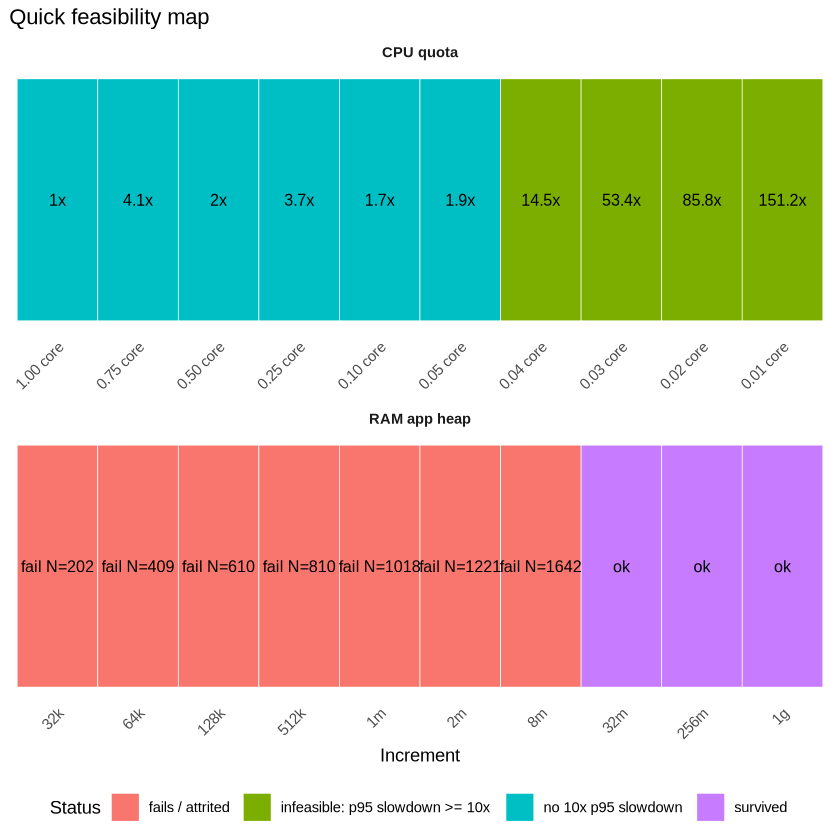

In [2]:
result$plots$quick_overview

In [3]:
result$run_inventory |>
  dplyr::select(run_id, run_kind, has_events, events_rows, has_resource_summary, has_worker_failures, outcome_class, terminal_finished) |>
  print(n = Inf, width = Inf)

# A tibble: 4 × 8
  run_id                                      run_kind           has_events events_rows has_resource_summary has_worker_failures
  <chr>                                       <chr>              <lgl>            <int> <lgl>                <lgl>              
1 .analysis_cache_v4                          other              FALSE                0 FALSE                FALSE              
2 cal01_cpu-quota-sweep_i1_20260703_024206    01 constrained CPU TRUE            312004 TRUE                 TRUE               
3 cal01_ram-app-heap-sweep_i1_20260703_024206 01 constrained RAM TRUE            103684 TRUE                 TRUE               
4 tmp02_20260702_143942_pid1589303_openmls    other              TRUE             20689 FALSE                FALSE              
  outcome_class             terminal_finished
  <chr>                     <lgl>            
1 unknown                   FALSE            
2 success                   TRUE             
3 success               

# A tibble: 10 × 13
   resource_profile_id app_heap_budget heap_bytes profile_index  runs profiled_workers failures survived first_failure_operation
   <chr>               <chr>                <dbl>         <dbl> <int>            <int>    <int>    <int> <chr>                  
 1 ram_app_heap_32k    32k                  32768             0     1                1        1        0 "key_package_create"   
 2 ram_app_heap_64k    64k                  65536             1     1                1        1        0 "key_package_create"   
 3 ram_app_heap_128k   128k                131072             2     1                1        1        0 "key_package_create"   
 4 ram_app_heap_512k   512k                524288             3     1                1        1        0 "welcome_receive"      
 5 ram_app_heap_1m     1m                 1048576             4     1                1        1        0 "welcome_receive"      
 6 ram_app_heap_2m     2m                 2097152             5     1        

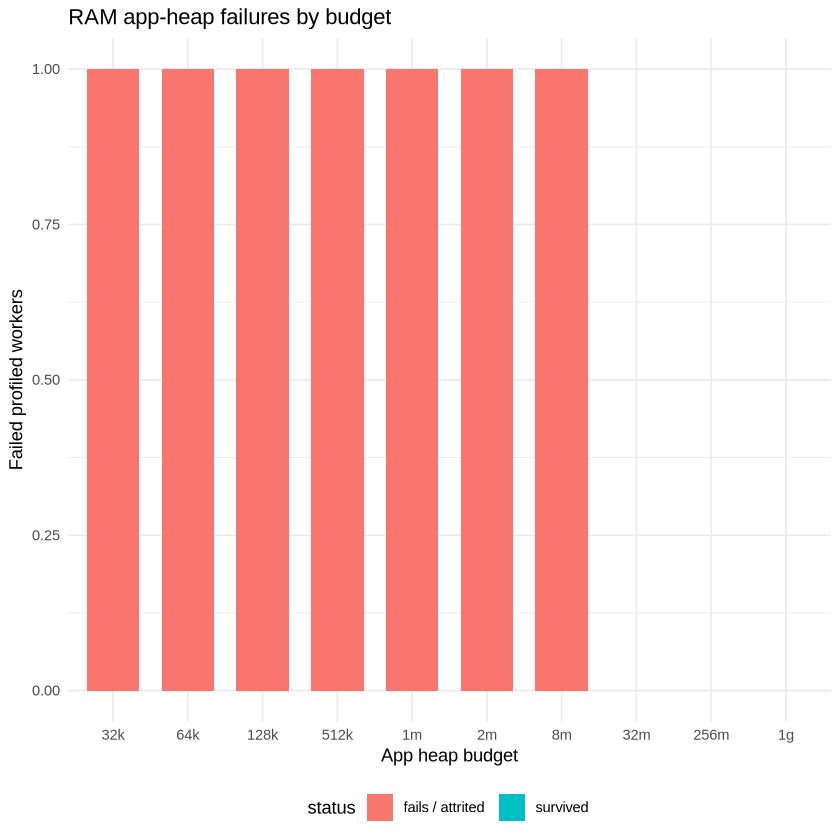

In [4]:
print(result$ram_table, n = Inf, width = Inf)
result$plots$ram_failures

# A tibble: 10 × 21
   resource_profile_id cpu_fraction cpu_limit profile_index  runs profiled_workers event_csv_available event_rows matched_operation_strata
   <chr>                      <dbl>     <dbl>         <dbl> <int>            <int> <lgl>                    <int>                    <int>
 1 cpu_quota_1p0               1         1                0     1                1 TRUE                      4878                       11
 2 cpu_quota_0p75              0.75      0.75             1     1                1 TRUE                      4286                       10
 3 cpu_quota_0p5               0.5       0.5              2     1                1 TRUE                      4078                        9
 4 cpu_quota_0p25              0.25      0.25             3     1                1 TRUE                      3886                       10
 5 cpu_quota_0p1               0.1       0.1              4     1                1 TRUE                      3678                        9
 6 cpu_

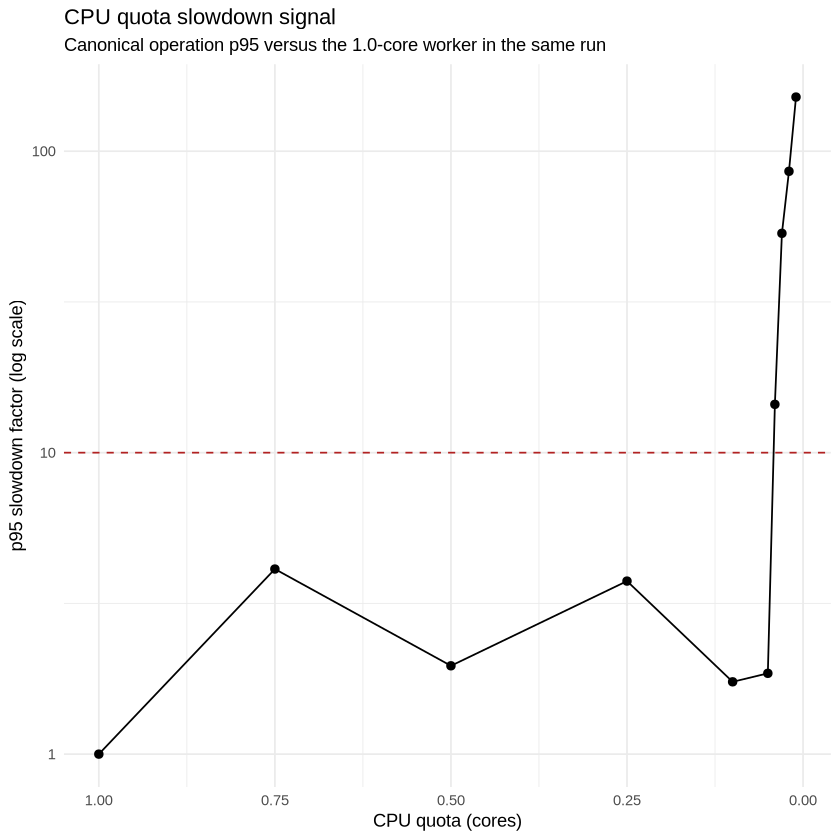

In [5]:
print(result$cpu_table, n = Inf, width = Inf)
result$plots$cpu_slowdown

# A tibble: 24 × 8
   run_kind           platform   operation_family                 n p50_wall_ms p95_wall_ms median_alloc_kib max_target_size
   <chr>              <chr>      <chr>                        <int>       <dbl>       <dbl>            <dbl>           <dbl>
 1 01 constrained CPU Containers welcome_receive                 72      2.88      4934.             2108.                NA
 2 01 constrained CPU Containers remove_commit_create           182      0.274      986.               48.9             1866
 3 01 constrained CPU Containers update_commit_create         14392      0.242      171.               66               2048
 4 01 constrained CPU Containers add_commit_create             8446      0.263       28.9             175.              2048
 5 01 constrained CPU Containers commit_receive              152668      0.230       22.3              53.1             2048
 6 01 constrained CPU Containers application_message_create   24672      0.0379       1.34              2.

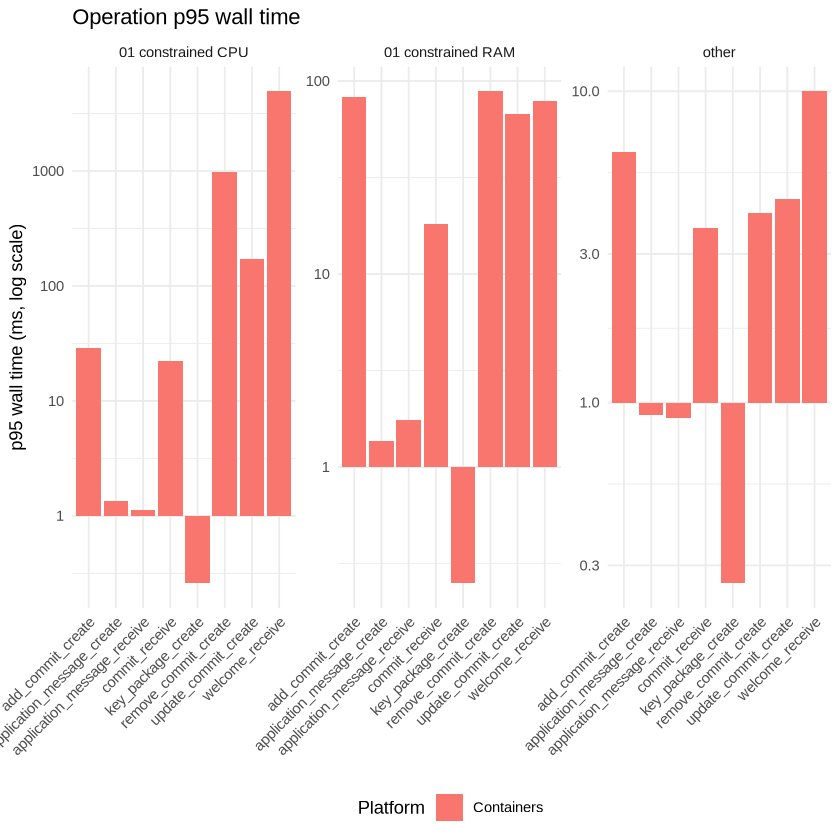

In [6]:
result$operation_summary |>
  dplyr::arrange(run_kind, platform, dplyr::desc(p95_wall_ms)) |>
  print(n = 80, width = Inf)
result$plots$operation_p95

# A tibble: 207 × 7
    run_kind           platform   operation_family            op                                                           n p95_wall_ms
    <chr>              <chr>      <chr>                       <chr>                                                    <int>       <dbl>
  1 01 constrained CPU Containers add_commit_create           commit_create_protocol_add                                 384     39.5   
  2 01 constrained CPU Containers add_commit_create           update_path_compute_protocol_core                          384     23.7   
  3 01 constrained CPU Containers add_commit_create           commit_add.path_hpke_encrypt                               384     19.2   
  4 01 constrained CPU Containers add_commit_create           welcome_create_protocol                                    384      9.89  
  5 01 constrained CPU Containers add_commit_create           commit_add.welcome_group_secrets_encrypt                   384      4.91  
  6 01 constrained CP

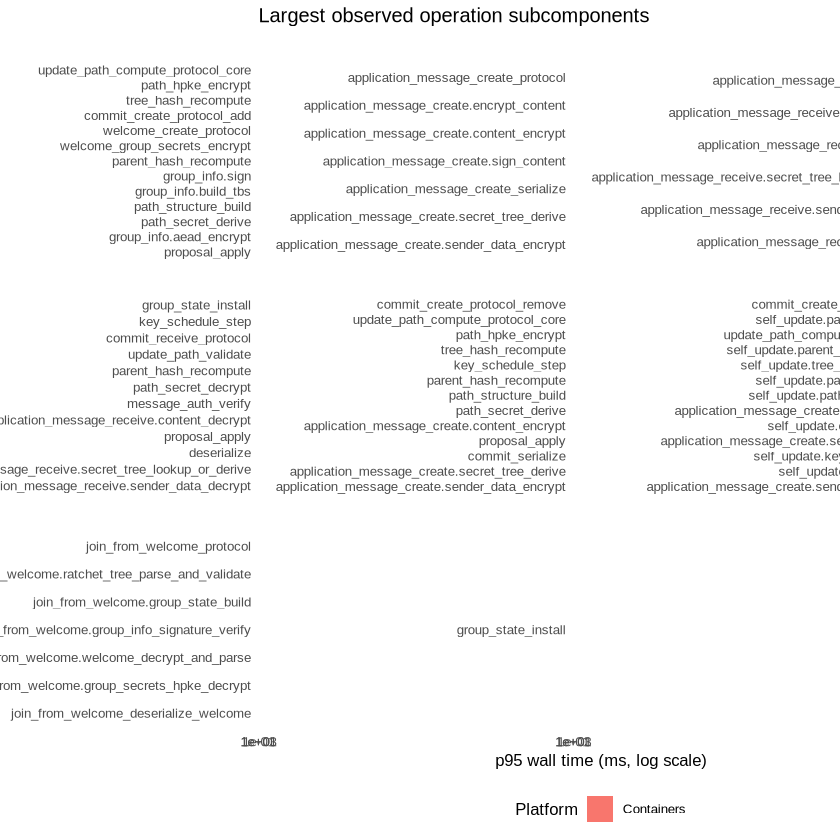

In [7]:
result$component_summary |>
  dplyr::arrange(run_kind, operation_family, dplyr::desc(p95_wall_ms)) |>
  print(n = 120, width = Inf)
result$plots$components

# A tibble: 0 × 5
# ℹ 5 variables: platform <chr>, operation_family <chr>, n <int>, p50_wall_ms <dbl>, p95_wall_ms <dbl>


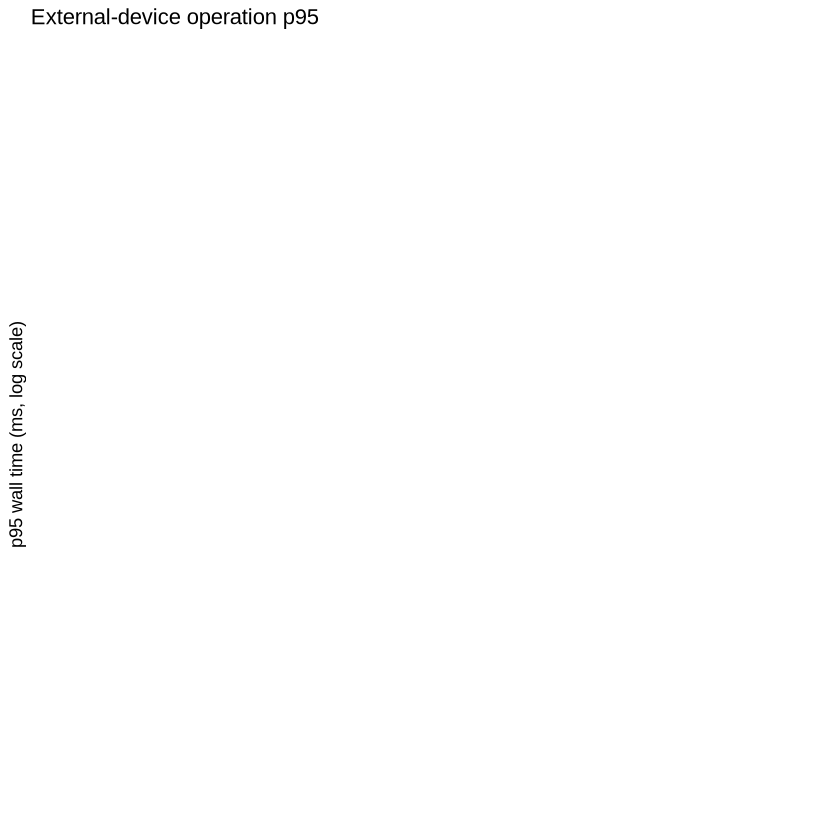

In [8]:
print(result$external_summary, n = Inf, width = Inf)
result$plots$external

In [9]:
list.files(result$output_dir, full.names = TRUE)

[1] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/01_quick_overview.png"      
 [2] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/02_ram_failures.png"        
 [3] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/03_cpu_slowdown.png"        
 [4] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/04_operation_p95.png"       
 [5] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/05_components.png"          
 [6] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/06_external_devices.png"    
 [7] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/component_summary.csv"      
 [8] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/cpu_slowdown_table.csv"     
 [9] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/external_device_summary.csv"
[10] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/operation_summary.csv"      
[11] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/quick_decision_table.csv"   
[12] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/ram_failure_table.csv"      
[13] "/home/docker/Schreibtisch/OpenMLS_Signal_Benchmark/statistics/analysis_output/openmls_v9/run_inventory.csv"